In [1]:

import numpy as np
import xarray as xr
import matplotlib as plt
import xrft as xt
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.tsa.seasonal import STL


ds1=xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Edited_plots/merged_files/pH_ensemble_ssp245_merged_r1.nc').squeeze()
ds1.squeeze()
ds1 = ds1.sel(time=slice('1985', '2100'))#.mean(['lat', 'lon'])
ds1 = 10**(-1*ds1)
# ds1 = ds1* 10**(9)

In [2]:
time = ds1['ph'].time
lat = ds1['ph'].lat
lon = ds1['ph'].lon

# Create an empty array to store residuals (same shape)
internal_variability = np.full(ds1['ph'].shape, np.nan)

# Loop over each spatial grid point
for i in range(len(lat)):
    for j in range(len(lon)):
        ts = ds1['ph'][:, i, j].values  # time series at (lat[i], lon[j])

        if np.all(np.isnan(ts)) or np.isnan(ts).sum() > 50:  # skip bad points
            continue

        try:
            stl = STL(ts, period=12, seasonal=13, trend=253, robust=True)
            res = stl.fit()
            internal_variability[:, i, j] = res.resid
        except:
            continue  # skip if STL fails (e.g., not enough valid data)

# Convert to xarray DataArray
internal_var_da = xr.DataArray(
    internal_variability,
    dims=("time", "lat", "lon"),
    coords={"time": time, "lat": lat, "lon": lon},
    name="internal_variability"
)

ImportError: Plotting of arrays of cftime.datetime objects or arrays indexed by cftime.datetime objects requires the optional `nc-time-axis` (v1.2.0 or later) package.

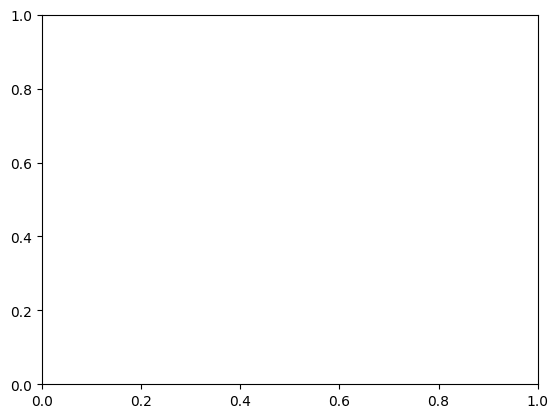

In [5]:
internal_var_da.sel(lon=60,lat=20, method='nearest').plot()

In [3]:
internal_var_da.to_netcdf('residual_H+_ssp245_r1.nc')

In [4]:
internal_var_da_ssp245 = internal_var_da.sel(time=slice('2015','2100'))
internal_var_da_hist = internal_var_da.sel(time=slice('1985','2014'))


In [5]:
internal_var_da_std_ssp245 = internal_var_da_ssp245.std(dim='time')

/home/athira/miniconda3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [6]:
internal_var_da_std_hist = internal_var_da_hist.std(dim='time')

/home/athira/miniconda3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


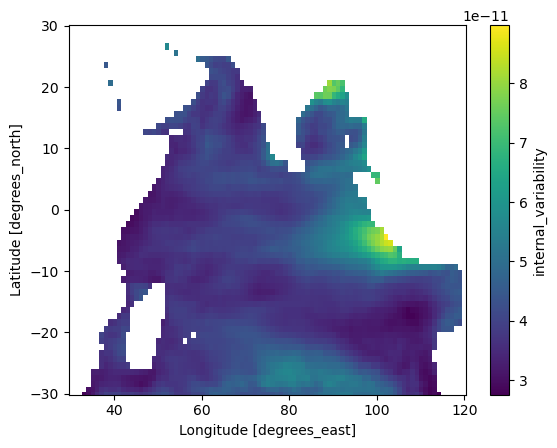

In [7]:
internal_var_da_std_hist.plot()

In [8]:
internal_var_da_std_ssp245.to_netcdf('UIN_STL_ssp245_H+.nc')

In [ ]:
# internal_var_da_std_hist.to_netcdf('UIN_STL_hist_H+.nc')